# Assignment 03 – Pie Chart of Email Domains

This notebook loads a CSV file containing 1000 people from:

https://drive.google.com/uc?id=1AWPf-pJodJKeHsARQK_RHiNsE8fjPCVK&export=download

It then:
- Extracts the email domains (e.g. `gmail.com`, `yahoo.com`),
- Counts how many people use each domain,
- Plots a nicely formatted pie chart of the most common email domains.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Make plots a bit larger and nicer by default
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["font.size"] = 12

In [4]:
# URL given in the assignment
csv_url = "https://drive.google.com/uc?id=1AWPf-pJodJKeHsARQK_RHiNsE8fjPCVK&export=download"

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_url)

# Take a quick look at the data
df.head()

,Index,User Id,First Name,Last Name,Sex,Email,Phone,Date of birth,Job Title
0,1,8717bbf45cCDbEe,Shelia,Mahoney,Male,pwarner@example.org,857.139.8239,2014-01-27,Probation officer
1,2,3d5AD30A4cD38ed,Jo,Rivers,Female,fergusonkatherine@example.net,+1-950-759-8687,1931-07-26,Dancer
2,3,810Ce0F276Badec,Sheryl,Lowery,Female,fhoward@example.org,(599)782-0605,2013-11-25,Copy
3,4,BF2a889C00f0cE1,Whitney,Hooper,Male,zjohnston@example.com,+1-939-130-6258,2012-11-17,Counselling psychologist
4,5,9afFEafAe1CBBB9,Lindsey,Rice,Female,elin@example.net,(390)417-1635x3010,1923-04-15,Biomedical engineer


In [6]:
# Try to automatically find the email column
email_cols = [col for col in df.columns if "mail" in col.lower()]

if not email_cols:
    raise ValueError("No column containing 'mail' found in the CSV columns: "
                     f"{list(df.columns)}")

email_col = email_cols[0]
print(f"Using email column: {email_col}")

# Extract the domain part of each email address
email_series = df[email_col].astype(str)

domains = (
    email_series
    .str.split("@").str[-1]      # part after '@'
    .str.strip()
    .str.lower()
)

# Check the first few domains
domains.head()

Using email column: Email


0    example.org
1    example.net
2    example.org
3    example.com
4    example.net
Name: Email, dtype: object

In [7]:
# Count how many times each domain appears
domain_counts = domains.value_counts()

# Show the top domains
domain_counts.head(10)

# Number of top domains to show explicitly
top_n = 5

top_domains = domain_counts.head(top_n)
other_count = domain_counts.iloc[top_n:].sum()

pie_data = top_domains.copy()

if other_count > 0:
    pie_data["Other"] = other_count

pie_data

Email
example.org    341
example.com    339
example.net    320
Name: count, dtype: int64

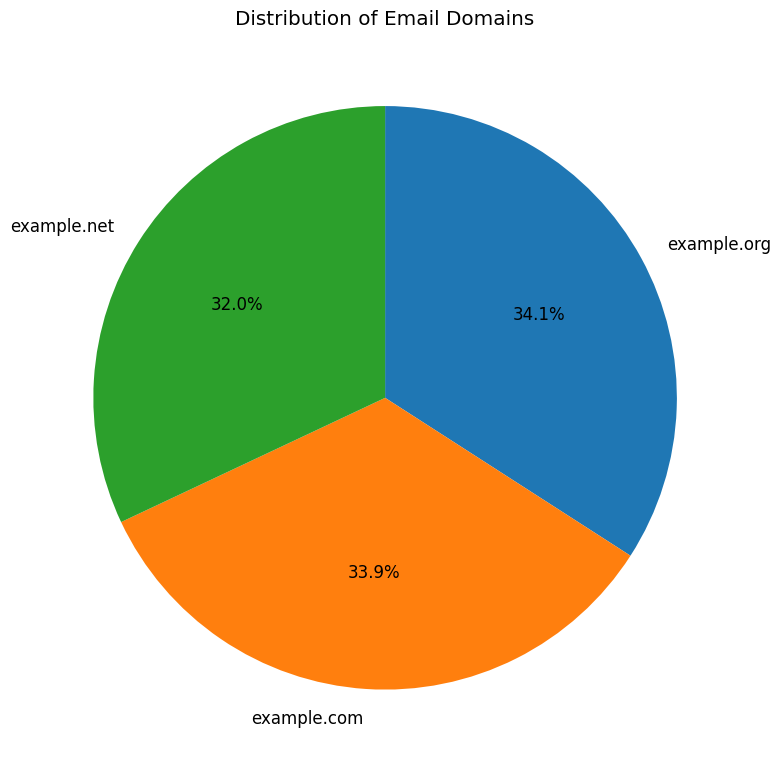

In [8]:
# Plot a nice pie chart of the email domains
plt.figure()

# Optional: set labels & values
labels = pie_data.index
sizes = pie_data.values

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",   # show percentages with 1 decimal place
    startangle=90,       # start at the top
    counterclock=False,  # slices go clockwise
)

plt.title("Distribution of Email Domains")
plt.axis("equal")        # make sure pie is a circle, not an ellipse
plt.tight_layout()
plt.show()